# Grover's Algorithm

## CNFの読み込み

In [ ]:
from cnf import Cnf

# sample cnfs are provided in the following file name format:
#     "samples/sample_{num_variables}_{num_clauses}.cnf"
cnf = Cnf.from_dimacs_file("samples/sample_3_3.cnf")

cnf

Cnf(clauses=[[1, 3, 2], [2, -1, -3], [1, 3, 1]], num_variables=3, num_clauses=3)

## 量子回路の設定

In [65]:
from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    AncillaRegister,
    ClassicalRegister,
)

variables_qubits = QuantumRegister(cnf.num_variables, "qv")
clauses_qubits = AncillaRegister(cnf.num_clauses, "qc")
oracle_qubit = AncillaRegister(1, "qo")
ancilla_qubits = AncillaRegister(1, "qa")
variables_clbits = ClassicalRegister(cnf.num_variables, "cv")

qc = QuantumCircuit(
    variables_qubits,
    clauses_qubits,
    oracle_qubit,
    ancilla_qubits,
    variables_clbits,
)

### 量子ビットの初期化

In [66]:
# 一様重ね合わせ状態
qc.h(variables_qubits)

# 前後の回路の合成を禁止
qc.barrier();

### 信託機械（オラクル, Oracle）の合成

In [67]:
from qiskit.circuit.library import MCXRecursive

clauses_effective_qubits = []
clauses_mcxs = []
for i, clause in enumerate(cnf.clauses):
    control_states = {}

    for literal in clause:
        variable = abs(literal) - 1
        control_state = int(literal < 0)
        if control_states.setdefault(variable, control_state) != control_state:
            break
    else:
        # sort + unzip
        variables, control_states = tuple(
            map(list, zip(*sorted(control_states.items(), key=lambda item: item[0])))
        )
        qs_control = [variables_qubits[v] for v in variables]
        control_state_str = "".join(map(str, control_states))

        gate = MCXRecursive(len(qs_control), ctrl_state=control_state_str)
        num_required_ancilla = (
            gate.num_ancilla_qubits if hasattr(gate, "num_ancilla_qubits") else 0
        )
        required_ancilla_qubits = ancilla_qubits[:num_required_ancilla]
        mcx = (gate, qs_control + [clauses_qubits[i]] + required_ancilla_qubits)

        clauses_effective_qubits.append(clauses_qubits[i])
        clauses_mcxs.append(mcx)

qc.x(clauses_effective_qubits)

for mcx in clauses_mcxs:
    qc.append(*mcx)

qc.mcx(clauses_effective_qubits, oracle_qubit, ancilla_qubits, "recursion")

for mcx in reversed(clauses_mcxs):
    qc.append(*mcx)

qc.x(clauses_effective_qubits)
qc.barrier();

### Grover iteration

In [68]:
qc.x(oracle_qubit)
qc.h(oracle_qubit)
qc.h(variables_qubits)
qc.x(variables_qubits)

qc.mcx(variables_qubits, oracle_qubit, ancilla_qubits, mode="recursion")

qc.x(variables_qubits)
qc.h(variables_qubits)
qc.h(oracle_qubit)
qc.x(oracle_qubit)
qc.h(oracle_qubit)
qc.barrier();

### 測定

In [69]:
qc.measure(variables_qubits, variables_clbits);

### 回路の表示

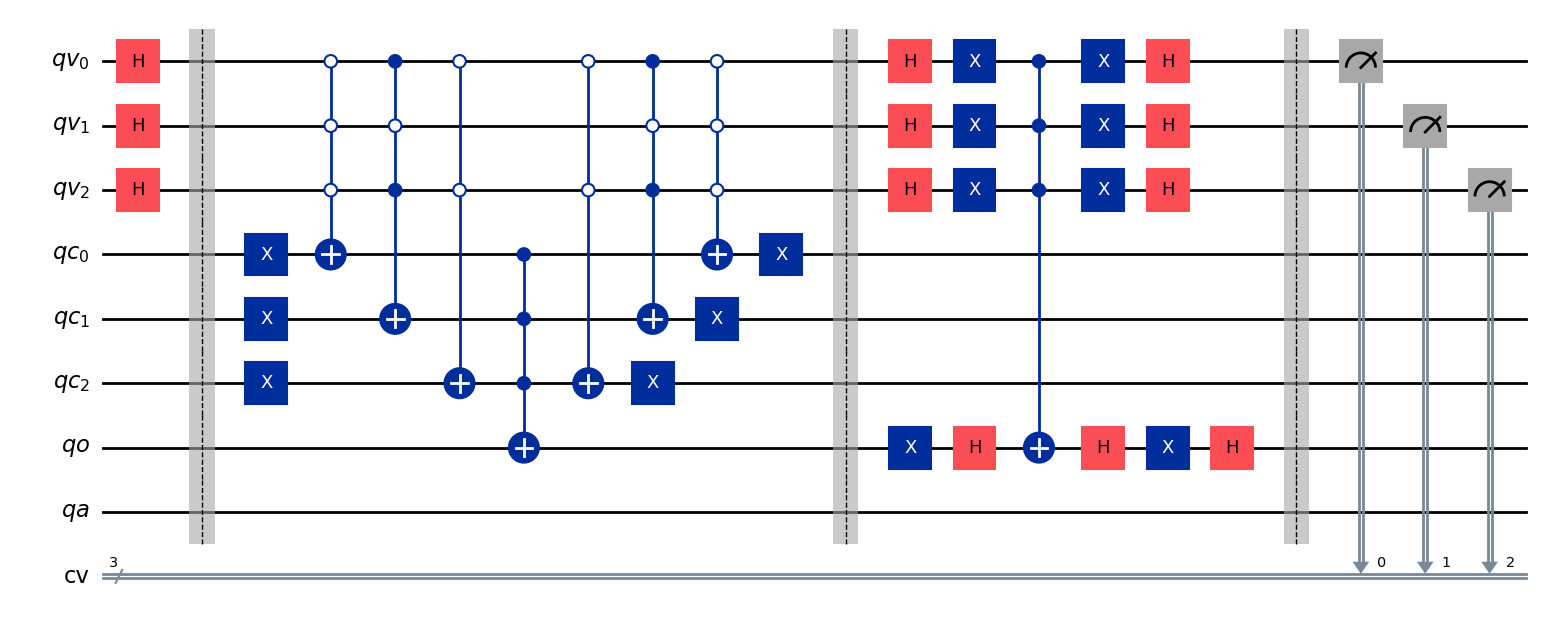

In [70]:
display(qc.draw("mpl"))

## 回路シミュレーション

In [71]:
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


simulator = AerSimulator()
qc_transpiled = transpile(qc, simulator)

job = simulator.run(qc_transpiled, shots=2**14)
result = job.result()
counts = result.get_counts(qc_transpiled)

### ヒストグラムの表示

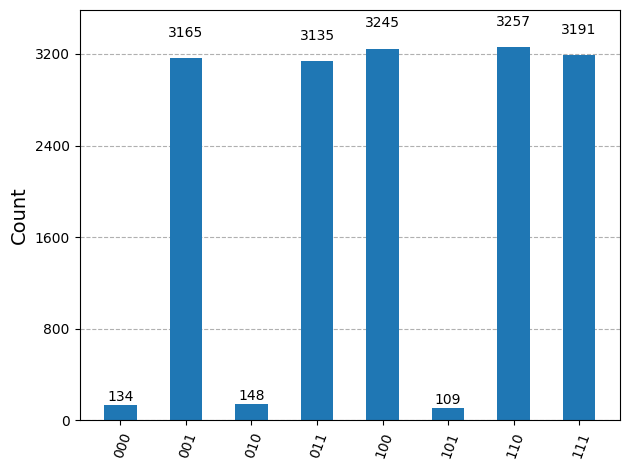

In [72]:
display(plot_histogram(counts))

### SATの解へ変換

In [73]:
plausible_bit_string = max(counts, key=counts.get)
plausible_solution = [int(b) for b in plausible_bit_string]

plausible_solution

[1, 1, 0]